In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Keras imports
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from keras.utils import image_dataset_from_directory
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

# Updated ImageDataGenerator import
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

# Sklearn imports
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# General imports
import random
import keras
import shutil
import tensorflow as tf

Class counts: [2055, 7970, 3323, 3140, 1257, 1702, 2079, 2103, 1677, 1847]


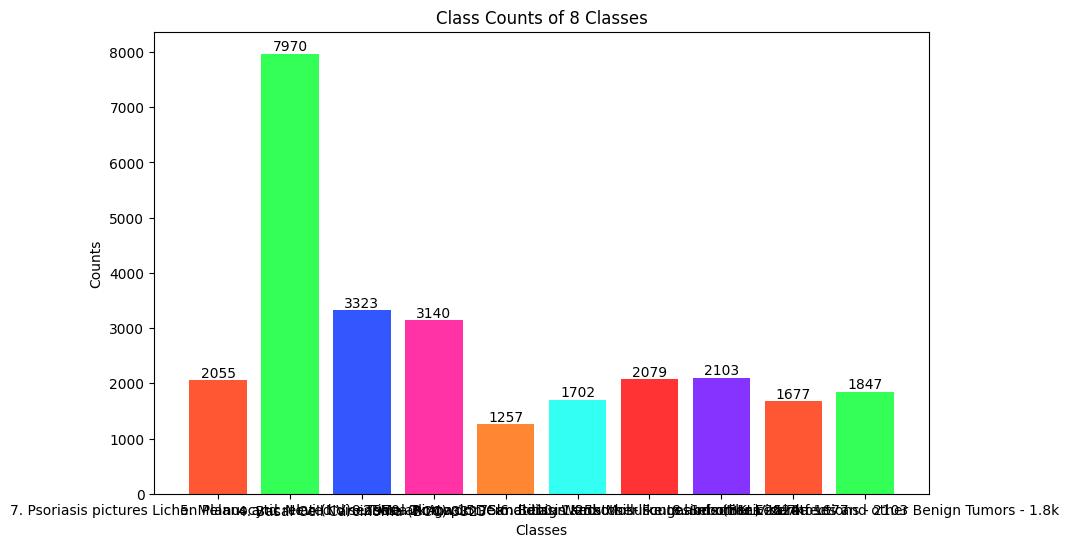

In [3]:
# Define paths
data_path = '/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES'
output_path = '/kaggle/working/Skin-disease-images'

# Remove existing dataset from working directory if it exists
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Copy the dataset to a writable directory
if not os.path.exists(output_path):
    shutil.copytree(data_path, output_path)

classes = os.listdir(output_path)
class_counts = [len(os.listdir(output_path + '/' + x)) for x in classes]
print("Class counts:", class_counts)

# Visualize class counts
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, class_counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6',
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts of 8 Classes')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}',
        ha='center',
        va='bottom'
    )
plt.show()

In [4]:
from PIL import Image

# Oversampler function
def oversampler(class_name, class_count, target=7000, batch_size=32, target_size=(224, 224)):
    datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    curr_dir = os.path.join(output_path, class_name)
    save_dir = curr_dir

    images = os.listdir(curr_dir)
    images = [os.path.join(curr_dir, img) for img in images]

    cnt = class_count

    while cnt < target:
        batch_images = []

        for img_path in random.sample(images, batch_size):
            img = Image.open(img_path)
            img = img.resize(target_size)
            img = np.array(img)
            batch_images.append(img)

        batch_images = np.array(batch_images)

        for _ in datagen.flow(batch_images, batch_size=batch_size,
                              save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
            cnt += batch_size
            if cnt >= target:
                break

        print(f"Processed {cnt}/{target} images for {class_name}")


# Undersampler function
def undersampler(class_name, class_count, target_count=7000):
    curr_dir = os.path.join(output_path, class_name)
    images = os.listdir(curr_dir)

    images_to_delete = random.sample(images, class_count - target_count)

    for image in images_to_delete:
        img_path = os.path.join(curr_dir, image)
        try:
            os.remove(img_path)
        except Exception as e:
            print(f"Error deleting {img_path}: {e}")

    print(f"Deleted {len(images_to_delete)} images for {class_name}")

Processed 7015/7000 images for 7. Psoriasis pictures Lichen Planus and related diseases - 2k
Deleted 970 images for 5. Melanocytic Nevi (NV) - 7970
Processed 7003/7000 images for 4. Basal Cell Carcinoma (BCC) 3323
Processed 7012/7000 images for 2. Melanoma 15.75k
Processed 7017/7000 images for 3. Atopic Dermatitis - 1.25k
Processed 7014/7000 images for 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
Processed 7007/7000 images for 6. Benign Keratosis-like Lesions (BKL) 2624
Processed 7031/7000 images for 10. Warts Molluscum and other Viral Infections - 2103
Processed 7021/7000 images for 1. Eczema 1677
Processed 7031/7000 images for 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Oversampling and undersampling completed successfully.
Class counts: [6980, 7000, 6982, 6987, 6971, 6974, 6972, 6995, 6980, 6994]


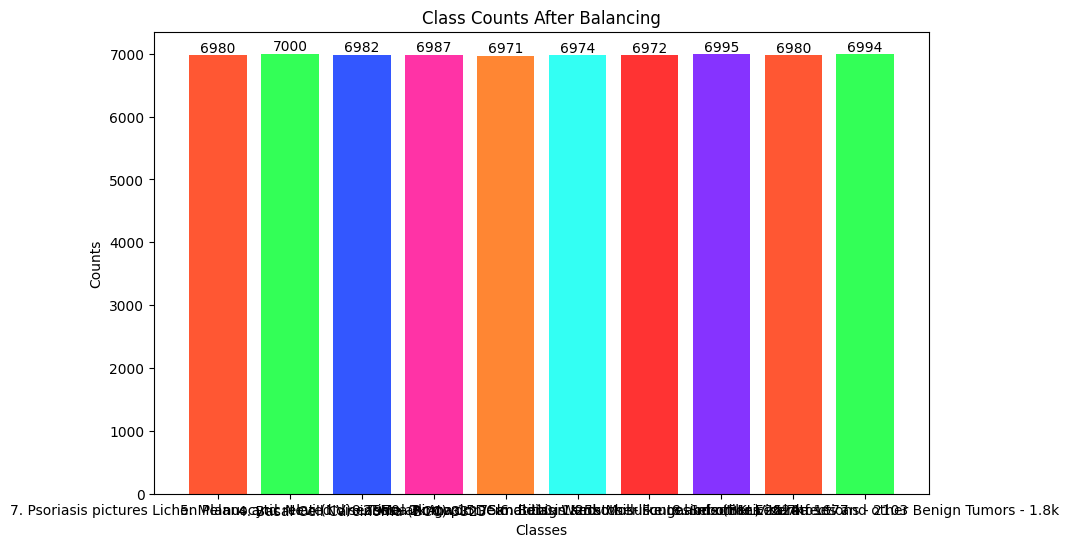

In [5]:
for i, class_name in enumerate(classes):
    if class_counts[i] < 7000:
        oversampler(class_name, class_counts[i])
    else:
        undersampler(class_name, class_counts[i])

print("Oversampling and undersampling completed successfully.")

# Verify class counts after balancing
classes = os.listdir(output_path)
class_counts = [len(os.listdir(output_path + '/' + x)) for x in classes]
print("Class counts:", class_counts)

# Visualize updated class counts
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, class_counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6',
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts After Balancing')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}',
        ha='center',
        va='bottom'
    )
plt.show()

In [6]:
import os
import random
import shutil

train_path = '/kaggle/working/train'
val_path = '/kaggle/working/val'
test_path = '/kaggle/working/test'

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

for class_folder in os.listdir(output_path):
    class_path = os.path.join(output_path, class_folder)

    train_class_path = os.path.join(train_path, class_folder)
    val_class_path = os.path.join(val_path, class_folder)
    test_class_path = os.path.join(test_path, class_folder)

    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(val_class_path, exist_ok=True)
    os.makedirs(test_class_path, exist_ok=True)

    images = os.listdir(class_path)
    random.shuffle(images)
    num_images = len(images)

    num_train = int(num_images * train_ratio)
    num_val = int(num_images * val_ratio)

    train_images = images[:num_train]
    val_images = images[num_train:num_train + num_val]
    test_images = images[num_train + num_val:]

    for image in train_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(train_class_path, image))
    for image in val_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(val_class_path, image))
    for image in test_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(test_class_path, image))

print("Dataset split completed successfully.")

Dataset split completed successfully.


In [7]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

img_size = (224, 224)
batch_size = 32

train_dataset = image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=123
)

class_names = train_dataset.class_names

val_dataset = image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=42
)

print("Class Names:", class_names)

Found 55865 files belonging to 10 classes.


I0000 00:00:1775638152.330299      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775638152.337938      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 6981 files belonging to 10 classes.
Class Names: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [8]:
@tf.function
def preprocess_image(image, label):
    image = tf.image.resize(image, [224, 224])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)  # MobileNetV2 specific
    return image, label

train_dataset = train_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

In [9]:
# Feature extractor using MobileNetV2
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='max'
)

for layer in base_model.layers:
    layer.trainable = False

# Build model
inputs = base_model.input
x = BatchNormalization()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Flatten()(x)
outputs = Dense(10, activation='softmax')(x)  # Adjust number of classes if needed

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 4,496,202 (17.15 MB)

 Trainable params: 2,235,658 (8.53 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_MobileNetV2.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

epochs = 50
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stopping, lr_reduction, checkpoint]
)

# Load best weights
model.load_weights("best_MobileNetV2.weights.h5")

# Save model
model_save_path = '/kaggle/working/MobileNetV2.h5'
model.save(model_save_path)
print(f'Model saved at {model_save_path}')

Epoch 1/50


I0000 00:00:1775638172.957732     162 service.cc:152] XLA service 0x7f7de4313850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775638172.957782     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775638172.957787     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775638174.234376     162 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-08 08:49:42.928692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:49:43.064738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775638185.458816     162 device_co

1744/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6925 - loss: 0.8657

2026-04-08 08:50:57.743518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:50:57.880062: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1746/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6926 - loss: 0.8654

2026-04-08 08:51:20.324913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:51:20.460710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.87051, saving model to best_MobileNetV2.weights.h5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 116s 56ms/step - accuracy: 0.6927 - loss: 0.8652 - val_accuracy: 0.8705 - val_loss: 0.3560 - learning_rate: 1.0000e-04
Epoch 2/50
1745/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8890 - loss: 0.3043
Epoch 2: val_accuracy improved from 0.87051 to 0.88669, saving model to best_MobileNetV2.weights.h5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 72s 41ms/step - accuracy: 0.8890 - loss: 0.3043 - val_accuracy: 0.8867 - val_loss: 0.3149 - learning_rate: 1.0000e-04
Epoch 3/50
1745/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9245 - loss: 0.2091
Epoch 3: val_accuracy improved from 0.88669 to 0.88884, saving model to best_MobileNetV2.weights.h5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 72s 41ms/step - accuracy: 0.9245 - loss: 0.2091 - val_accuracy: 0.8888 - val_loss: 0.3295 - learning_rate: 1.0000e-04
Epoch 4/50
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9510 - 

Model saved at /kaggle/working/MobileNetV2.h5


Found 6989 files belonging to 10 classes.


2026-04-08 08:59:13.818554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:59:13.956233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:59:14.092948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.90      0.88      0.89       698
           10. Warts Molluscum and other Viral Infections - 2103       0.89      0.89      0.89       700
                                              2. Melanoma 15.75k       0.95      0.92      0.94       700
                                    3. Atopic Dermatitis - 1.25k       0.90      0.88      0.89       698
                              4. Basal Cell Carcinoma (BCC) 3323       0.91      0.95      0.93       699
                                 5. Melanocytic Nevi (NV) - 7970       0.87      0.92      0.89       700
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.92      0.88      0.90       698
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.85      0.86      0.85       698
          8. Seborrhe

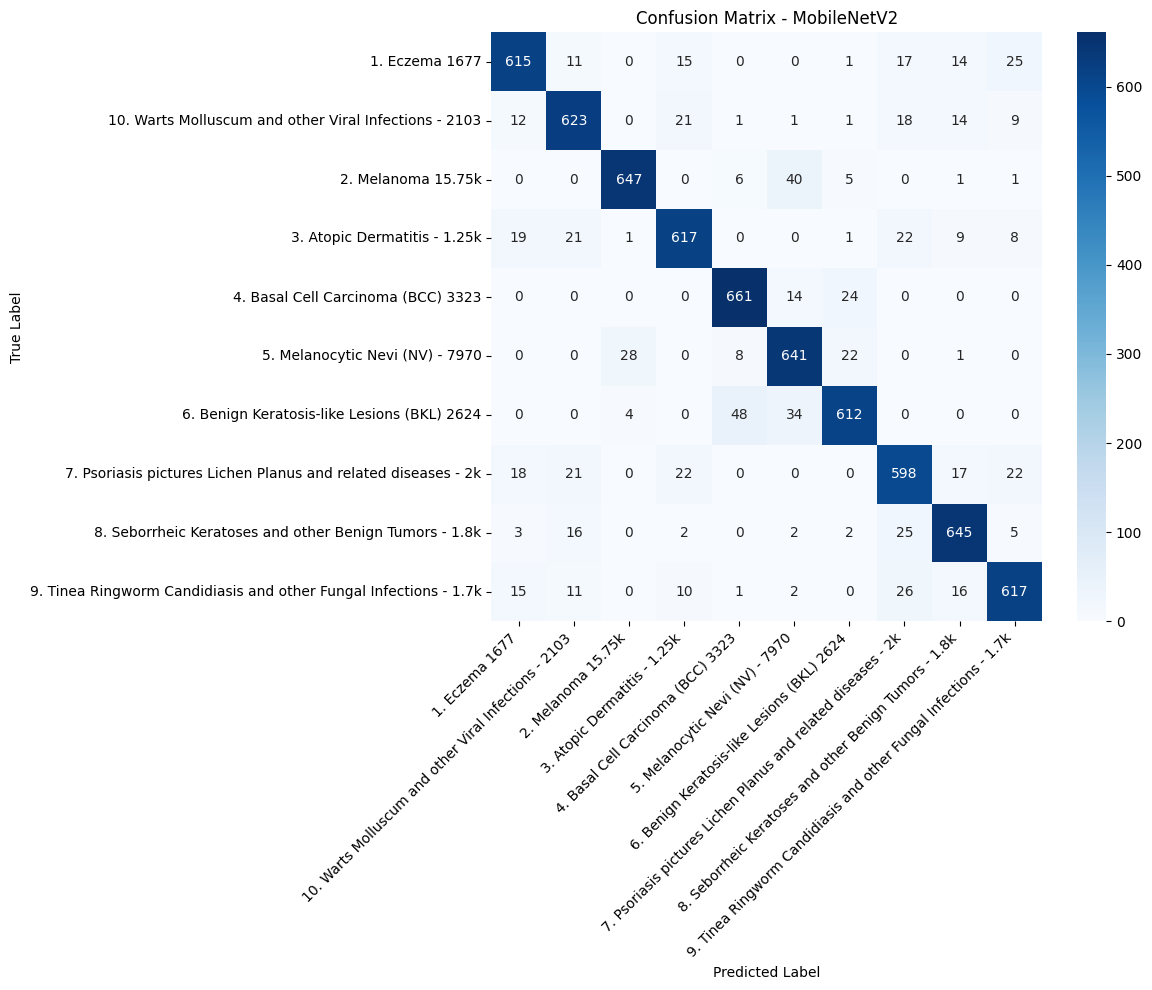

In [11]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image_dataset_from_directory

raw_test_dataset = image_dataset_from_directory(
    '/kaggle/working/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

class_names = raw_test_dataset.class_names
test_dataset = raw_test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

y_true, y_pred, y_prob = [], [], []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

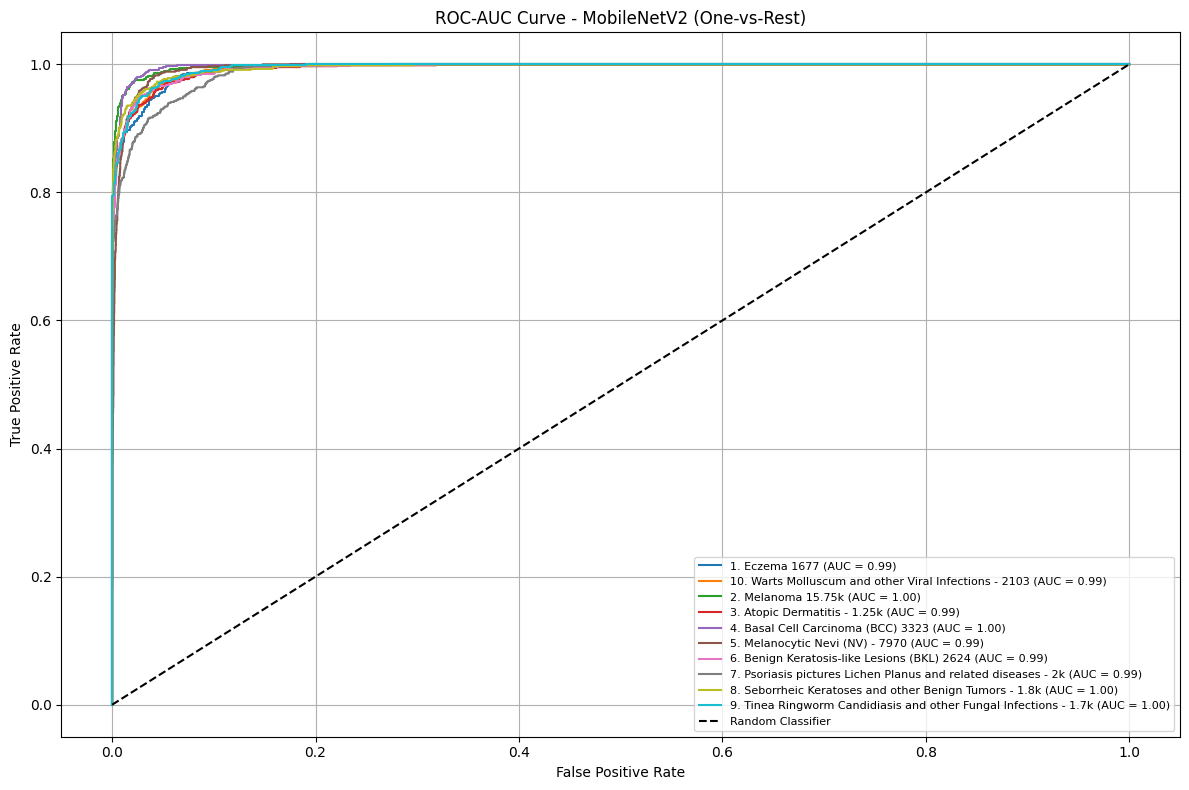


Mean AUC Score: 0.9947


In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

plt.figure(figsize=(12, 8))
auc_scores = []

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - MobileNetV2 (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMean AUC Score: {np.mean(auc_scores):.4f}")

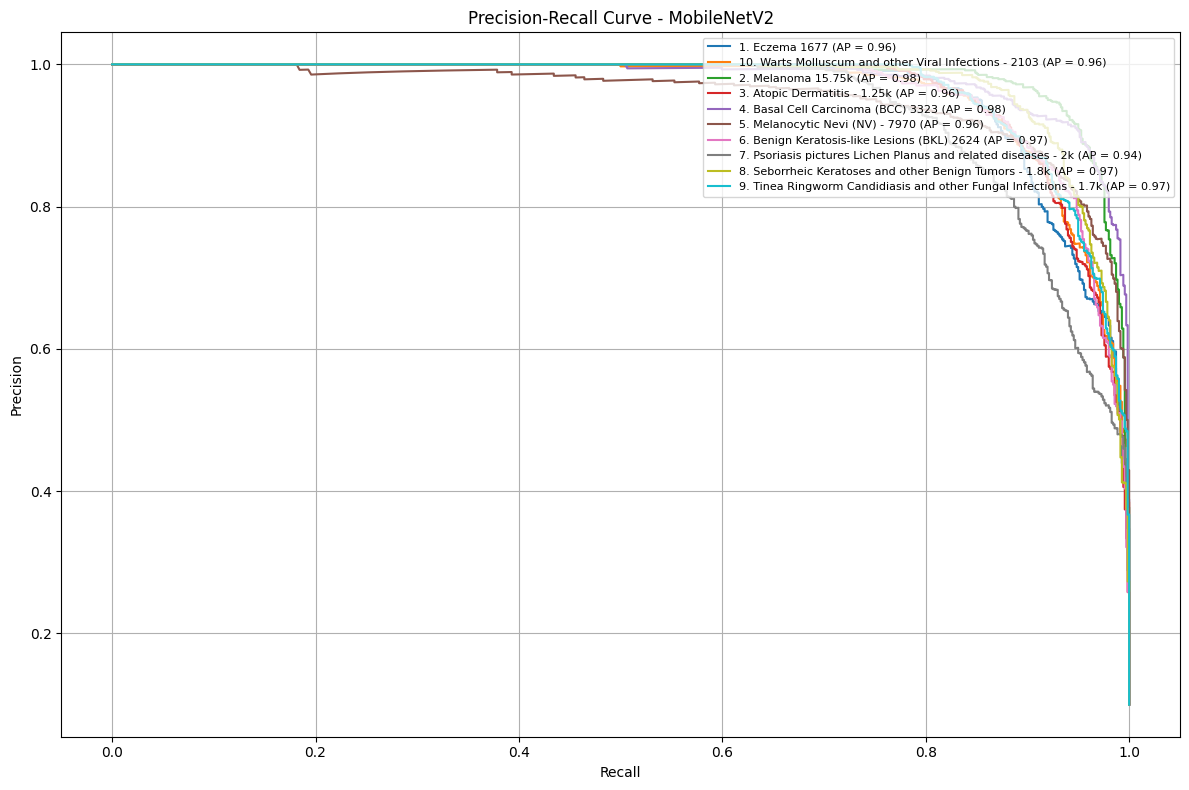


Mean Average Precision (mAP): 0.9658


In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(12, 8))
ap_scores = []

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    ap_scores.append(ap)
    plt.plot(recall, precision, label=f'{class_names[i]} (AP = {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - MobileNetV2')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMean Average Precision (mAP): {np.mean(ap_scores):.4f}")

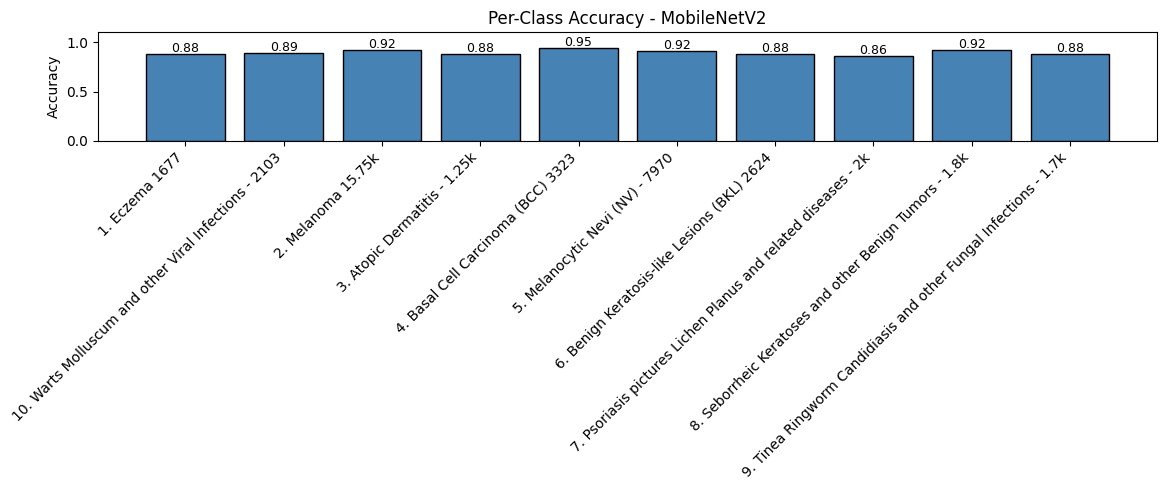


===== Overall Metrics Summary - MobileNetV2 =====
Accuracy:              0.8980
Balanced Accuracy:     0.8980
Macro F1-Score:        0.8980
Weighted F1-Score:     0.8980
Mean AUC:              0.9947
Mean Avg Precision:    0.9658


In [14]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy - MobileNetV2')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n===== Overall Metrics Summary - MobileNetV2 =====")
print(f"Accuracy:              {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:     {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1-Score:        {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score:     {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Mean AUC:              {np.mean(auc_scores):.4f}")
print(f"Mean Avg Precision:    {np.mean(ap_scores):.4f}")

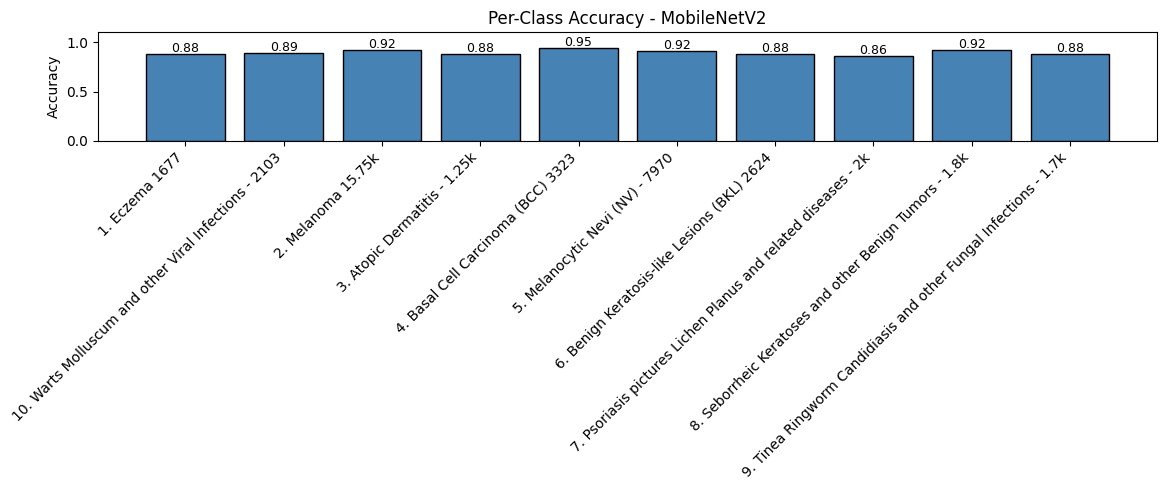


===== Overall Metrics Summary - MobileNetV2 =====
Accuracy:              0.8980
Balanced Accuracy:     0.8980
Macro F1-Score:        0.8980
Weighted F1-Score:     0.8980
Mean AUC:              0.9947
Mean Avg Precision:    0.9658


In [15]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy - MobileNetV2')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n===== Overall Metrics Summary - MobileNetV2 =====")
print(f"Accuracy:              {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:     {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1-Score:        {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score:     {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Mean AUC:              {np.mean(auc_scores):.4f}")
print(f"Mean Avg Precision:    {np.mean(ap_scores):.4f}")